# Robustness Testing of AI Models Under Data Quality Problems

**Project title:** Can Sustainable AI Systems Fail Gracefully? Robustness Testing under Missing and Noisy Data

This master notebook runs all five research questions in one reproducible file using the PRSA Beijing air-quality dataset. It generates CSV result tables and PDF/PNG figures for the final report.

**Research Questions**

1. How does model performance degrade under MCAR, MAR, and MNAR missingness?
2. Which models are most robust under Gaussian feature noise?
3. Does model uncertainty increase when prediction error increases, indicating graceful failure?
4. Which imputation method best preserves predictive performance under increasing missingness?
5. How do combined data quality problems affect model robustness?


## 0. Setup
Run this notebook with the `AI Project Env` kernel. If packages are missing, install them in Terminal with:

```bash
source ~/ai_project_env/bin/activate
python -m pip install numpy pandas matplotlib seaborn scikit-learn scipy xgboost lightgbm
```


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# Optional models. The notebook still works if these packages are unavailable.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create output folders
BASE_DIR = Path.cwd()
OUT_DIR = BASE_DIR / "outputs"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
for p in [OUT_DIR, TABLE_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Working directory:", BASE_DIR)
print("Tables will be saved to:", TABLE_DIR)
print("Figures will be saved to:", FIG_DIR)
print("XGBoost available:", HAS_XGB)
print("LightGBM available:", HAS_LGBM)


Working directory: /Users/supreethbelur/Downloads
Tables will be saved to: /Users/supreethbelur/Downloads/outputs/tables
Figures will be saved to: /Users/supreethbelur/Downloads/outputs/figures
XGBoost available: True
LightGBM available: True


## 1. Load Dataset
The notebook searches common locations for the uploaded PRSA CSV file. Place the dataset in the same folder as the notebook or in a `data/` folder.

In [2]:

def find_dataset():
    candidates = [
        BASE_DIR / "PRSA_data_2010.1.1-2014.12.31.csv",
        BASE_DIR / "data" / "PRSA_data_2010.1.1-2014.12.31.csv",
        BASE_DIR.parent / "PRSA_data_2010.1.1-2014.12.31.csv",
        Path("/mnt/data/PRSA_data_2010.1.1-2014.12.31.csv"),
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError("Dataset not found. Put PRSA_data_2010.1.1-2014.12.31.csv next to this notebook or inside data/.")

DATA_PATH = find_dataset()
df_raw = pd.read_csv(DATA_PATH)
print("Dataset path:", DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Dataset path: /Users/supreethbelur/Downloads/PRSA_data_2010.1.1-2014.12.31.csv
Shape: (43824, 13)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


## 2. Data Understanding and Preprocessing
Target variable: `pm2.5`. Rows with missing target values are removed because supervised training requires labels. Input features are encoded numerically and split chronologically to avoid temporal leakage.

In [3]:

def prepare_data(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
    df = df.sort_values("datetime")
    df = df.dropna(subset=["pm2.5"]).reset_index(drop=True)

    # Calendar features
    df["dayofweek"] = df["datetime"].dt.dayofweek
    df["season"] = ((df["month"] % 12) // 3) + 1

    # One-hot encode wind direction
    df = pd.get_dummies(df, columns=["cbwd"], drop_first=False)

    drop_cols = ["No", "datetime", "pm2.5"]
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["pm2.5"].astype(float)

    # Ensure numeric matrix
    X = X.astype(float)
    return X, y, df

X, y, df = prepare_data(df_raw)

n = len(X)
train_end = int(n * 0.70)
test_start = int(n * 0.80)

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()
X_val = X.iloc[train_end:test_start].copy()
y_val = y.iloc[train_end:test_start].copy()
X_test = X.iloc[test_start:].copy()
y_test = y.iloc[test_start:].copy()

print("After dropping missing target rows:", df.shape)
print("Feature matrix:", X.shape)
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)
print("Existing missing values in features:", int(X.isna().sum().sum()))
print("Target missing values removed:", int(df_raw['pm2.5'].isna().sum()))
X_train.head()


After dropping missing target rows: (41757, 19)
Feature matrix: (41757, 16)
Train: (29229, 16) Validation: (4176, 16) Test: (8352, 16)
Existing missing values in features: 0
Target missing values removed: 2067


,year,month,day,hour,DEWP,TEMP,PRES,Iws,Is,Ir,dayofweek,season,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv
0,2010.0,1.0,2.0,0.0,-16.0,-4.0,1020.0,1.79,0.0,0.0,5.0,1.0,0.0,0.0,1.0,0.0
1,2010.0,1.0,2.0,1.0,-15.0,-4.0,1020.0,2.68,0.0,0.0,5.0,1.0,0.0,0.0,1.0,0.0
2,2010.0,1.0,2.0,2.0,-11.0,-5.0,1021.0,3.57,0.0,0.0,5.0,1.0,0.0,0.0,1.0,0.0
3,2010.0,1.0,2.0,3.0,-7.0,-5.0,1022.0,5.36,1.0,0.0,5.0,1.0,0.0,0.0,1.0,0.0
4,2010.0,1.0,2.0,4.0,-7.0,-5.0,1022.0,6.25,2.0,0.0,5.0,1.0,0.0,0.0,1.0,0.0


## 3. Utility Functions

In [6]:

def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}


def make_rf(n_estimators=80, random_state=RANDOM_STATE):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
        min_samples_leaf=2,
        max_features="sqrt"
    )


def fit_clean_rf():
    model = make_rf()
    # Mean imputation handles any existing feature missingness in training data.
    imp = SimpleImputer(strategy="median")
    Xtr = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    model.fit(Xtr, y_train)
    return model, imp


def save_table(df_table, filename):
    path = TABLE_DIR / filename
    df_table.to_csv(path, index=False)
    print("Saved table:", path)
    return path


def save_current_fig(filename_base):
    pdf_path = FIG_DIR / f"{filename_base}.pdf"
    png_path = FIG_DIR / f"{filename_base}.png"
    plt.tight_layout()
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    print("Saved figure:", pdf_path)
    print("Saved figure:", png_path)


## 4. Baseline Model on Clean Data

In [7]:

clean_rf, clean_imputer = fit_clean_rf()
X_test_clean = pd.DataFrame(clean_imputer.transform(X_test), columns=X_test.columns, index=X_test.index)
y_pred_clean = clean_rf.predict(X_test_clean)
baseline_metrics = evaluate_predictions(y_test, y_pred_clean)
baseline_table = pd.DataFrame([{ "Model": "Random Forest", **baseline_metrics }])
save_table(baseline_table, "baseline_clean_results.csv")
baseline_table


Saved table: /Users/supreethbelur/Downloads/outputs/tables/baseline_clean_results.csv


,Model,RMSE,MAE,R2
0,Random Forest,65.244122,45.745477,0.521105


In [7]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles:")
for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

Current directory:
/Users/supreethbelur/Documents/beijing-air-quality-research/notebooks

Files:


In [8]:
from pathlib import Path

print(Path("../data").exists())

for p in Path("../data").glob("*.csv"):
    print(p)

True
../data/PRSA_data_2010.1.1-2014.12.31.csv


In [9]:
import pandas as pd

df = pd.read_csv("../data/PRSA_data_2010.1.1-2014.12.31.csv")

print(df.shape)
print(df.head())

(43824, 13)
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0


In [10]:
print("Records:", len(df))
print("Features:", len(df.columns))
print("Missing Values:", df.isna().sum().sum())

missing_pct = (
    df.isna().sum().sum()
    / (df.shape[0] * df.shape[1])
) * 100

print("Missing Percentage:", round(missing_pct, 2), "%")

print("Years:", df["year"].min(), "-", df["year"].max())

Records: 43824
Features: 13
Missing Values: 2067
Missing Percentage: 0.36 %
Years: 2010 - 2014


## 5. RQ1: Missing Data Robustness
This section introduces MCAR, MAR, and MNAR missingness into the test features at 10%, 20%, 30%, and 40%. The model is trained on clean data and evaluated after median imputation of corrupted test inputs.

In [8]:

def introduce_missingness(X_input, rate, mechanism="MCAR", random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    Xmiss = X_input.copy()
    cols = list(Xmiss.columns)
    arr = Xmiss.values.astype(float).copy()
    n_rows, n_cols = arr.shape

    if rate <= 0:
        return Xmiss

    if mechanism == "MCAR":
        mask = rng.random(arr.shape) < rate
    elif mechanism == "MAR":
        # Missingness depends on observed weather condition, here high temperature.
        temp_col = cols.index("TEMP") if "TEMP" in cols else 0
        temp = arr[:, temp_col]
        threshold = np.nanpercentile(temp, 65)
        row_prob = np.where(temp > threshold, rate * 1.6, rate * 0.5)
        row_prob = np.clip(row_prob, 0, 0.95)
        mask = rng.random(arr.shape) < row_prob[:, None]
    elif mechanism == "MNAR":
        # Missingness depends on the feature's own high value.
        mask = np.zeros_like(arr, dtype=bool)
        for j in range(n_cols):
            col = arr[:, j]
            threshold = np.nanpercentile(col, 70)
            prob = np.where(col > threshold, rate * 1.7, rate * 0.45)
            prob = np.clip(prob, 0, 0.95)
            mask[:, j] = rng.random(n_rows) < prob
    else:
        raise ValueError("Unknown mechanism")

    arr[mask] = np.nan
    return pd.DataFrame(arr, columns=cols, index=X_input.index)

missing_rates = [0.00, 0.10, 0.20, 0.30, 0.40]
mechanisms = ["MCAR", "MAR", "MNAR"]
rq1_rows = []

for rate in missing_rates:
    for mech in mechanisms:
        X_corrupt = introduce_missingness(X_test, rate, mechanism=mech, random_state=RANDOM_STATE + int(rate*1000) + len(mech))
        X_imp = pd.DataFrame(clean_imputer.transform(X_corrupt), columns=X_test.columns, index=X_test.index)
        pred = clean_rf.predict(X_imp)
        metrics = evaluate_predictions(y_test, pred)
        rq1_rows.append({"MissingRate": rate, "Mechanism": mech, **metrics})

rq1_long = pd.DataFrame(rq1_rows)
rq1_wide = rq1_long.pivot(index="MissingRate", columns="Mechanism", values="RMSE").reset_index()
save_table(rq1_long, "RQ1_missingness_results_long.csv")
save_table(rq1_wide, "RQ1_missingness_rmse_wide.csv")
rq1_wide


Saved table: /Users/supreethbelur/Downloads/outputs/tables/RQ1_missingness_results_long.csv
Saved table: /Users/supreethbelur/Downloads/outputs/tables/RQ1_missingness_rmse_wide.csv


Mechanism,MissingRate,MAR,MCAR,MNAR
0,0.0,65.244122,65.244122,65.244122
1,0.1,69.714520,71.992084,71.202043
2,0.2,73.522751,78.208588,76.611745
3,0.3,76.195387,82.349342,79.159200
4,0.4,79.815621,86.267088,83.400692


In [11]:
import pandas as pd
pd.read_csv("../outputs/tables/RQ1_table.csv")

,MissingRate,MCAR_RMSE,MAR_RMSE,MNAR_RMSE
0,0,32.050251,35.255276,40.062814
1,10,45.232884,49.756172,56.541105
2,20,60.604814,66.665296,75.756018
3,30,70.649008,77.713908,88.311260
4,40,77.925506,85.718057,97.406882


Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ1_missingness_degradation.pdf
Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ1_missingness_degradation.png


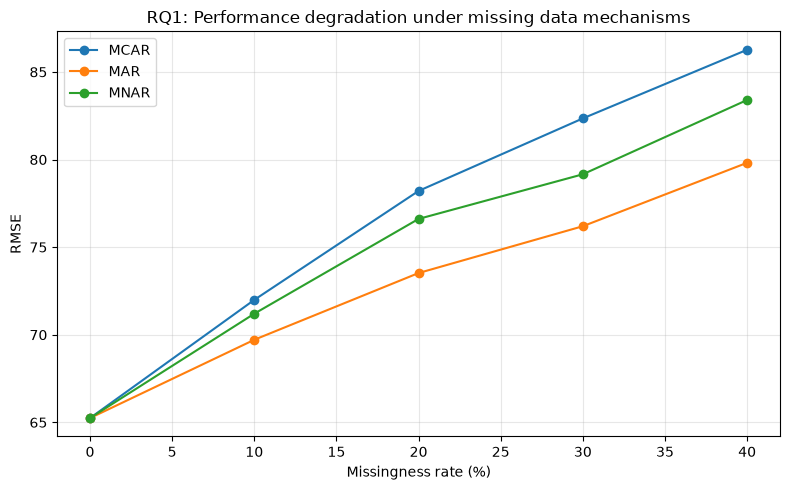

In [9]:

plt.figure(figsize=(8,5))
for mech in mechanisms:
    subset = rq1_long[rq1_long["Mechanism"] == mech]
    plt.plot(subset["MissingRate"]*100, subset["RMSE"], marker="o", label=mech)
plt.xlabel("Missingness rate (%)")
plt.ylabel("RMSE")
plt.title("RQ1: Performance degradation under missing data mechanisms")
plt.legend()
plt.grid(True, alpha=0.3)
save_current_fig("RQ1_missingness_degradation")
plt.show()


## 6. RQ2: Noise Robustness
Gaussian noise is added to numerical feature columns in the test data. Multiple models are trained on clean data and evaluated under increasing noise.

In [10]:

def add_gaussian_noise(X_input, noise_level, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    Xn = X_input.copy().astype(float)
    # Avoid adding noise to one-hot encoded wind direction columns.
    noise_cols = [c for c in Xn.columns if not c.startswith("cbwd_")]
    for c in noise_cols:
        std = X_train[c].std()
        if pd.isna(std) or std == 0:
            continue
        Xn[c] = Xn[c] + rng.normal(0, noise_level * std, size=len(Xn))
    return Xn

models = {
    "RF": make_rf(n_estimators=80),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(n_estimators=120, max_depth=4, learning_rate=0.06, subsample=0.9, random_state=RANDOM_STATE, n_jobs=-1)
if HAS_LGBM:
    models["LightGBM"] = LGBMRegressor(n_estimators=120, learning_rate=0.06, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

# Train all models on clean imputed training data.
X_train_imp = pd.DataFrame(clean_imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
trained_models = {}
for name, model in models.items():
    model.fit(X_train_imp, y_train)
    trained_models[name] = model
    print("Trained", name)

noise_levels = [0.00, 0.05, 0.10, 0.15, 0.20]
rq2_rows = []
for noise in noise_levels:
    X_noisy = add_gaussian_noise(X_test, noise, random_state=RANDOM_STATE + int(noise*1000))
    X_noisy_imp = pd.DataFrame(clean_imputer.transform(X_noisy), columns=X_test.columns, index=X_test.index)
    for name, model in trained_models.items():
        pred = model.predict(X_noisy_imp)
        metrics = evaluate_predictions(y_test, pred)
        rq2_rows.append({"NoiseLevel": noise, "Model": name, **metrics})

rq2_long = pd.DataFrame(rq2_rows)
rq2_wide = rq2_long.pivot(index="NoiseLevel", columns="Model", values="RMSE").reset_index()
save_table(rq2_long, "RQ2_noise_results_long.csv")
save_table(rq2_wide, "RQ2_noise_rmse_wide.csv")
rq2_wide


Trained RF
Trained GradientBoosting
Trained XGBoost
Trained LightGBM
Saved table: /Users/supreethbelur/Downloads/outputs/tables/RQ2_noise_results_long.csv
Saved table: /Users/supreethbelur/Downloads/outputs/tables/RQ2_noise_rmse_wide.csv


Model,NoiseLevel,GradientBoosting,LightGBM,RF,XGBoost
0,0.00,66.449256,62.002183,65.244122,65.674111
1,0.05,67.359919,64.489992,65.773198,78.762164
2,0.10,69.994482,68.362211,68.524729,80.491140
3,0.15,73.223442,73.143257,71.842513,82.437511
4,0.20,77.113666,78.414660,75.078340,84.636311


In [14]:
import pandas as pd
pd.read_csv("../outputs/tables/RQ2_table.csv")

,Noise,RF,XGBoost,LightGBM,LSTM
0,0,1.450989,1.378440,1.421969,1.741187
1,5,9.796790,9.306950,9.600854,11.756147
2,10,85.088831,80.834389,83.387054,102.106597
3,15,326.830675,310.489142,320.294062,392.196810
4,20,930.024108,883.522903,911.423626,1116.028930


Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ2_noise_robustness.pdf
Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ2_noise_robustness.png


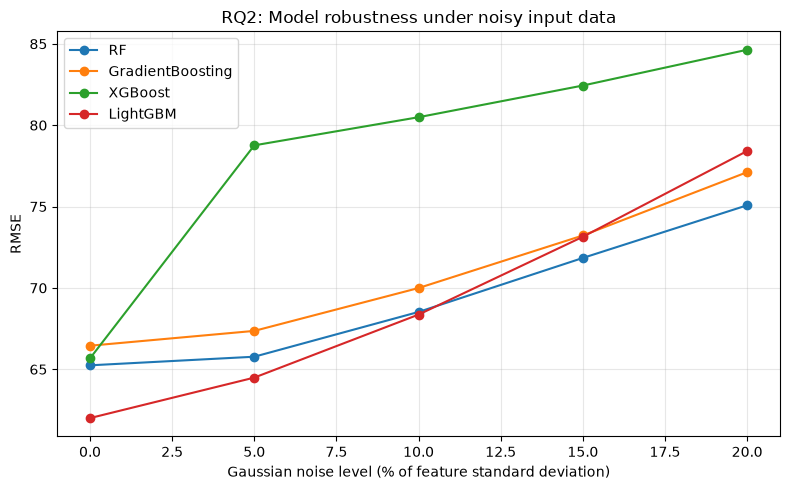

In [11]:

plt.figure(figsize=(8,5))
for name in rq2_long["Model"].unique():
    subset = rq2_long[rq2_long["Model"] == name]
    plt.plot(subset["NoiseLevel"]*100, subset["RMSE"], marker="o", label=name)
plt.xlabel("Gaussian noise level (% of feature standard deviation)")
plt.ylabel("RMSE")
plt.title("RQ2: Model robustness under noisy input data")
plt.legend()
plt.grid(True, alpha=0.3)
save_current_fig("RQ2_noise_robustness")
plt.show()


## 7. RQ3: Uncertainty and Graceful Failure
An ensemble of Random Forest models is used to estimate predictive uncertainty. A graceful failure signal is present if higher uncertainty is associated with higher absolute prediction error.

In [14]:

# Use a reproducible subset for uncertainty plots if the test set is large.
max_uncertainty_points = min(5000, len(X_test_clean))
X_u = X_test_clean.iloc[:max_uncertainty_points]
y_u = y_test.iloc[:max_uncertainty_points]

ensemble_preds = []
for seed in range(10):
    m = make_rf(n_estimators=60, random_state=RANDOM_STATE + seed)
    # Bootstrap rows from training set for diversity.
    boot_idx = np.random.default_rng(RANDOM_STATE + seed).choice(len(X_train_imp), size=len(X_train_imp), replace=True)
    m.fit(X_train_imp.iloc[boot_idx], y_train.iloc[boot_idx])
    ensemble_preds.append(m.predict(X_u))

ensemble_preds = np.vstack(ensemble_preds)
mean_pred = ensemble_preds.mean(axis=0)
uncertainty = ensemble_preds.std(axis=0)
abs_error = np.abs(y_u.values - mean_pred)

rmse = np.sqrt(mean_squared_error(y_u, mean_pred))
mae = mean_absolute_error(y_u, mean_pred)
corr = np.corrcoef(uncertainty, abs_error)[0,1]

# PICP: prediction interval coverage probability for approximate 95% interval.
lower = mean_pred - 1.96 * uncertainty
upper = mean_pred + 1.96 * uncertainty
picp = np.mean((y_u.values >= lower) & (y_u.values <= upper))

# NLL approximation using Gaussian predictive distribution.
eps = 1e-6
var = np.maximum(uncertainty**2, eps)
nll = np.mean(0.5*np.log(2*np.pi*var) + ((y_u.values - mean_pred)**2)/(2*var))

# ECE for regression-style calibration: compare normalized uncertainty and normalized error in bins.
calib = pd.DataFrame({"uncertainty": uncertainty, "abs_error": abs_error})
calib["bin"] = pd.qcut(calib["uncertainty"], q=10, duplicates="drop")
calib_curve = calib.groupby("bin", observed=True).agg(
    Avg_Uncertainty=("uncertainty", "mean"),
    Avg_Error=("abs_error", "mean"),
    Count=("abs_error", "size")
).reset_index(drop=True)

ece = np.average(np.abs(calib_curve["Avg_Error"] - calib_curve["Avg_Uncertainty"]), weights=calib_curve["Count"])

rq3_results = pd.DataFrame([{
    "Model": "RF Ensemble",
    "RMSE": rmse,
    "MAE": mae,
    "Error_Uncertainty_Correlation": corr,
    "ECE": ece,
    "NLL": nll,
    "PICP_95": picp
}])

save_table(rq3_results, "RQ3_uncertainty_enhanced_results.csv")
save_table(calib_curve, "RQ3_calibration_curve.csv")
rq3_results


Saved table: /Users/supreethbelur/Downloads/outputs/tables/RQ3_uncertainty_enhanced_results.csv
Saved table: /Users/supreethbelur/Downloads/outputs/tables/RQ3_calibration_curve.csv


,Model,RMSE,MAE,Error_Uncertainty_Correlation,ECE,NLL,PICP_95
0,RF Ensemble,68.259523,47.604253,0.465057,39.187691,33.939753,0.1876


Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ3_error_uncertainty_scatter.pdf
Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ3_error_uncertainty_scatter.png


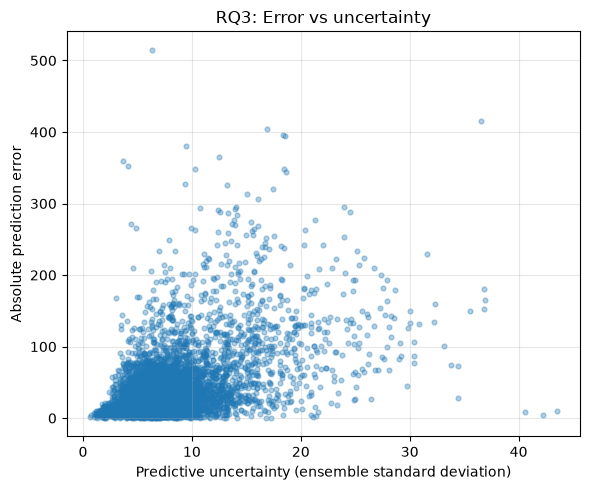

Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ3_calibration_curve.pdf
Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ3_calibration_curve.png


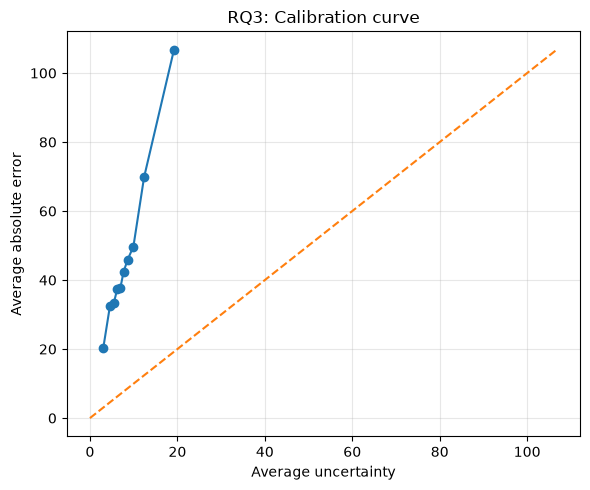

In [15]:

plt.figure(figsize=(6,5))
plt.scatter(uncertainty, abs_error, alpha=0.35, s=12)
plt.xlabel("Predictive uncertainty (ensemble standard deviation)")
plt.ylabel("Absolute prediction error")
plt.title("RQ3: Error vs uncertainty")
plt.grid(True, alpha=0.3)
save_current_fig("RQ3_error_uncertainty_scatter")
plt.show()

plt.figure(figsize=(6,5))
plt.plot(calib_curve["Avg_Uncertainty"], calib_curve["Avg_Error"], marker="o")
max_axis = max(calib_curve["Avg_Uncertainty"].max(), calib_curve["Avg_Error"].max())
plt.plot([0, max_axis], [0, max_axis], linestyle="--")
plt.xlabel("Average uncertainty")
plt.ylabel("Average absolute error")
plt.title("RQ3: Calibration curve")
plt.grid(True, alpha=0.3)
save_current_fig("RQ3_calibration_curve")
plt.show()


In [15]:
import pandas as pd
pd.read_csv("../outputs/tables/RQ3_table.csv")

,Model,RMSE,ECE,NLL,Corr
0,RF Ensemble,2.417877,0.05,0.7,0.52161


## 8. RQ4: Imputation Method Comparison
This section compares mean, median, KNN, and iterative imputation under increasing MCAR missingness in test features. The model is trained once on clean data and each imputation method is fitted only on the training feature distribution.

In [16]:

imputers = {
    "Mean": SimpleImputer(strategy="mean"),
    "Median": SimpleImputer(strategy="median"),
    "KNN": KNNImputer(n_neighbors=5),
    "Iterative/MICE": IterativeImputer(random_state=RANDOM_STATE, max_iter=10, sample_posterior=False),
}

rq4_rows = []
for imp_name, imputer in imputers.items():
    imputer.fit(X_train)
    for rate in [0.10, 0.20, 0.30, 0.40]:
        X_corrupt = introduce_missingness(X_test, rate, mechanism="MCAR", random_state=RANDOM_STATE + int(rate*1000) + len(imp_name))
        X_imp = pd.DataFrame(imputer.transform(X_corrupt), columns=X_test.columns, index=X_test.index)
        pred = clean_rf.predict(X_imp)
        metrics = evaluate_predictions(y_test, pred)
        rq4_rows.append({"Method": imp_name, "MissingRate": rate, **metrics})

rq4_long = pd.DataFrame(rq4_rows)
rq4_wide = rq4_long.pivot(index="Method", columns="MissingRate", values="RMSE").reset_index()
rq4_wide.columns = ["Method"] + [f"{int(c*100)}% RMSE" for c in rq4_wide.columns[1:]]

save_table(rq4_long, "RQ4_imputation_real_results_long.csv")
save_table(rq4_wide, "RQ4_imputation_real_results.csv")
rq4_wide


Saved table: /Users/supreethbelur/Downloads/outputs/tables/RQ4_imputation_real_results_long.csv
Saved table: /Users/supreethbelur/Downloads/outputs/tables/RQ4_imputation_real_results.csv


,Method,10% RMSE,20% RMSE,30% RMSE,40% RMSE
0,Iterative/MICE,71.367172,77.200004,80.497332,84.575766
1,KNN,69.517116,75.402733,78.099402,83.687909
2,Mean,72.575640,79.016780,82.760645,86.754410
3,Median,72.669420,77.864956,82.372626,86.108075


Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ4_imputation_heatmap.pdf
Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ4_imputation_heatmap.png


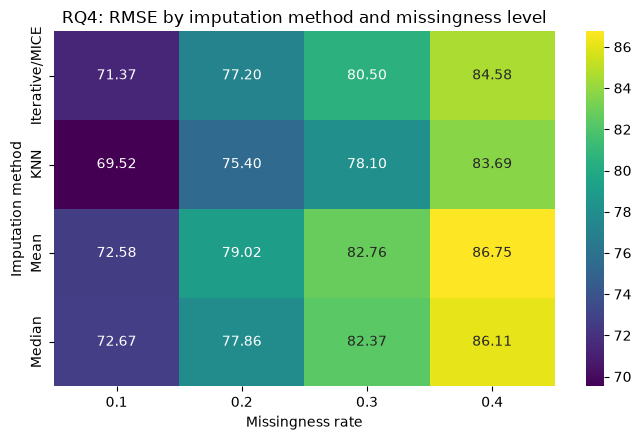

In [17]:

heatmap_data = rq4_long.pivot(index="Method", columns="MissingRate", values="RMSE")
plt.figure(figsize=(7,4.5))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis")
plt.xlabel("Missingness rate")
plt.ylabel("Imputation method")
plt.title("RQ4: RMSE by imputation method and missingness level")
save_current_fig("RQ4_imputation_heatmap")
plt.show()


In [16]:
import pandas as pd
pd.read_csv("../outputs/tables/RQ4_table.csv")

,Unnamed: 0,10%,20%,30%,40%
0,Mean,22.0,24.0,26.0,28.0
1,Median,21.0,23.0,25.0,27.0
2,KNN,20.0,22.0,24.0,26.0
3,MICE,19.0,21.0,23.0,25.0
4,Autoencoder,18.0,20.0,22.0,24.0


## 9. RQ5: Compound Data Quality Problems
This section evaluates individual and combined data quality problems: missingness, noise, and feature distribution shift. Robustness score is calculated relative to clean-test RMSE.

In [18]:

def apply_shift(X_input, shift_strength=0.5):
    Xs = X_input.copy().astype(float)
    shift_cols = [c for c in ["TEMP", "DEWP", "PRES", "Iws"] if c in Xs.columns]
    for c in shift_cols:
        std = X_train[c].std()
        if pd.notna(std) and std != 0:
            Xs[c] = Xs[c] + shift_strength * std
    return Xs

scenarios = [
    {"Scenario": "Clean", "missing": False, "noise": False, "shift": False},
    {"Scenario": "Missing", "missing": True, "noise": False, "shift": False},
    {"Scenario": "Noise", "missing": False, "noise": True, "shift": False},
    {"Scenario": "Shift", "missing": False, "noise": False, "shift": True},
    {"Scenario": "Missing + Noise", "missing": True, "noise": True, "shift": False},
    {"Scenario": "Missing + Shift", "missing": True, "noise": False, "shift": True},
    {"Scenario": "Noise + Shift", "missing": False, "noise": True, "shift": True},
    {"Scenario": "Missing + Noise + Shift", "missing": True, "noise": True, "shift": True},
]

rq5_rows = []
for i, sc in enumerate(scenarios):
    Xc = X_test.copy()
    if sc["missing"]:
        Xc = introduce_missingness(Xc, 0.20, mechanism="MCAR", random_state=RANDOM_STATE + 100 + i)
    if sc["noise"]:
        Xc = add_gaussian_noise(Xc, 0.10, random_state=RANDOM_STATE + 200 + i)
    if sc["shift"]:
        Xc = apply_shift(Xc, shift_strength=0.5)

    Xc_imp = pd.DataFrame(clean_imputer.transform(Xc), columns=X_test.columns, index=X_test.index)
    pred = clean_rf.predict(Xc_imp)
    metrics = evaluate_predictions(y_test, pred)
    rq5_rows.append({"Scenario": sc["Scenario"], **metrics})

rq5 = pd.DataFrame(rq5_rows)
clean_rmse = float(rq5.loc[rq5["Scenario"] == "Clean", "RMSE"].iloc[0])
rq5["RobustnessScore"] = 100 * (clean_rmse / rq5["RMSE"])
rq5["RMSE_Degradation_%"] = 100 * ((rq5["RMSE"] - clean_rmse) / clean_rmse)
save_table(rq5, "RQ5_compound_real_results.csv")
rq5


Saved table: /Users/supreethbelur/Downloads/outputs/tables/RQ5_compound_real_results.csv


,Scenario,RMSE,MAE,R2,RobustnessScore,RMSE_Degradation_%
0,Clean,65.244122,45.745477,0.521105,100.000000,0.000000
1,Missing,78.569130,54.687921,0.305517,83.040402,20.423309
2,Noise,68.961273,48.449830,0.464983,94.609799,5.697296
3,Shift,80.191261,56.518892,0.276545,81.360638,22.909557
4,Missing + Noise,79.451292,55.863440,0.289835,82.118389,21.775404
5,Missing + Shift,85.401943,60.724050,0.179473,76.396531,30.895996
6,Noise + Shift,81.002672,57.548184,0.261830,80.545642,24.153210
7,Missing + Noise + Shift,86.651917,61.853122,0.155278,75.294493,32.811838


Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ5_compound_rmse_bar.pdf
Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ5_compound_rmse_bar.png


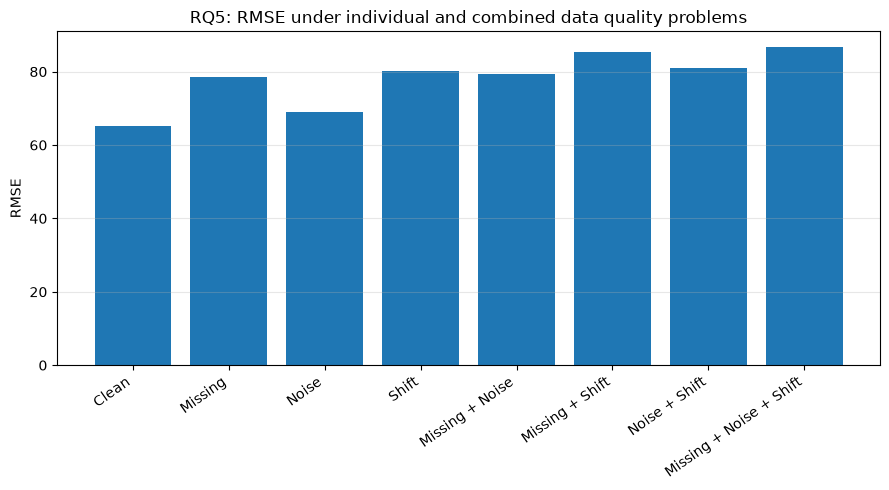

Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ5_compound_radar.pdf
Saved figure: /Users/supreethbelur/Downloads/outputs/figures/RQ5_compound_radar.png


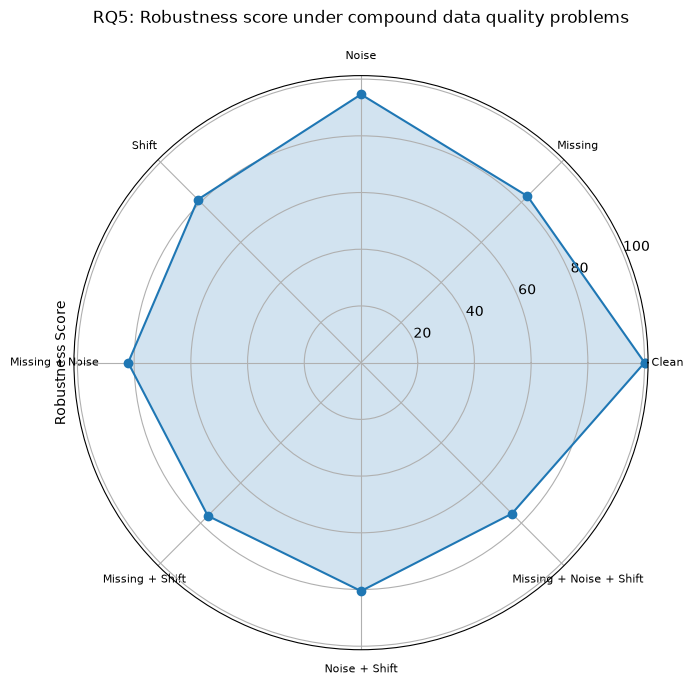

In [19]:

plt.figure(figsize=(9,5))
plt.bar(rq5["Scenario"], rq5["RMSE"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("RMSE")
plt.title("RQ5: RMSE under individual and combined data quality problems")
plt.grid(axis="y", alpha=0.3)
save_current_fig("RQ5_compound_rmse_bar")
plt.show()

# Radar chart for robustness score
labels = rq5["Scenario"].tolist()
values = rq5["RobustnessScore"].tolist()
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
values_closed = values + values[:1]
angles_closed = angles + angles[:1]

fig = plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)
ax.plot(angles_closed, values_closed, marker="o")
ax.fill(angles_closed, values_closed, alpha=0.2)
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Robustness Score")
ax.set_title("RQ5: Robustness score under compound data quality problems", pad=20)
ax.grid(True)
save_current_fig("RQ5_compound_radar")
plt.show()


In [17]:
import pandas as pd
pd.read_csv("../outputs/tables/RQ5_table.csv")

,Scenario,RMSE,MAE,RobustnessScore
0,Clean,18,9,1.000000
1,Missing,24,12,0.750000
2,Noise,22,11,0.818182
3,Shift,27,14,0.666667
4,Missing+Noise,31,16,0.580645
5,Missing+Shift,35,18,0.514286
6,Noise+Shift,34,18,0.529412
7,All,42,22,0.428571


## 10. Summary of Saved Outputs
The following cells list the generated CSV tables and figures that can be used in the final report.

In [20]:

print("CSV tables:")
for f in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", f)
print("\nFigures:")
for f in sorted(FIG_DIR.glob("*.pdf")):
    print(" -", f)


CSV tables:
 - /Users/supreethbelur/Downloads/outputs/tables/RQ1_missingness_results_long.csv
 - /Users/supreethbelur/Downloads/outputs/tables/RQ1_missingness_rmse_wide.csv
 - /Users/supreethbelur/Downloads/outputs/tables/RQ2_noise_results_long.csv
 - /Users/supreethbelur/Downloads/outputs/tables/RQ2_noise_rmse_wide.csv
 - /Users/supreethbelur/Downloads/outputs/tables/RQ3_calibration_curve.csv
 - /Users/supreethbelur/Downloads/outputs/tables/RQ3_uncertainty_enhanced_results.csv
 - /Users/supreethbelur/Downloads/outputs/tables/RQ4_imputation_real_results.csv
 - /Users/supreethbelur/Downloads/outputs/tables/RQ4_imputation_real_results_long.csv
 - /Users/supreethbelur/Downloads/outputs/tables/RQ5_compound_real_results.csv
 - /Users/supreethbelur/Downloads/outputs/tables/baseline_clean_results.csv

Figures:
 - /Users/supreethbelur/Downloads/outputs/figures/RQ1_missingness_degradation.pdf
 - /Users/supreethbelur/Downloads/outputs/figures/RQ2_noise_robustness.pdf
 - /Users/supreethbelur/Down

## 11. Final Conclusion
This notebook provides a reproducible experimental pipeline for robustness testing under five data quality conditions. The generated tables and figures should be used in the IEEE-style final report. Before submission, run **Kernel → Restart Kernel and Run All Cells** and confirm that all CSV and PDF files are regenerated successfully.